In [1]:
import os
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter

from net import BERTClassifier
from data import LoadDataset
from train import train

In [2]:
dataset_dir = "/root/autodl-tmp/BertClassifier/dataset"
dataset_path = "/root/autodl-tmp/BertClassifier/dataset/News_Category_Dataset_v3.json"
local_model_path = "/root/models/bert-base-uncased"

batch_size = 1024
num_workers = os.cpu_count() // 2
class_weights = True

dropout = 0.2

num_epochs = 5
lr={"bert": 1e-4, "outputs": 1e-3}

In [3]:
train_set = LoadDataset(torch.load(f'{dataset_dir}/train.pt'))
test_set = LoadDataset(torch.load(f'{dataset_dir}/test.pt'))
c_weights = torch.load(f'{dataset_dir}/class_weights.pt')

# 加权重采样/降采样
train_labels = [data[-1].item() for data in train_set]
class_counts = Counter(train_labels)

sample_weights = [1.0 / class_counts[data[-1].item()] for data in train_set]
sampler = WeightedRandomSampler(sample_weights, num_samples=(len(sample_weights) * 2))

# train_iter = DataLoader(train_set, batch_size, shuffle=True, num_workers=num_workers)
train_iter = DataLoader(train_set, batch_size=batch_size, sampler=sampler)
test_iter = DataLoader(test_set, batch_size, shuffle=False, num_workers=num_workers)

loss 0.244, train acc 0.849, test acc 0.302
2.2 examples/sec on [device(type='cuda', index=0)]


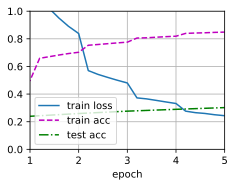

In [5]:
net = BERTClassifier(local_model_path, dropout)

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # class weights
        self.gamma = gamma

    def forward(self, inputs, targets):
        self.alpha = self.alpha.to(inputs.device)
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

loss = FocalLoss(c_weights, gamma=1.0)
# loss = nn.MSELoss()

params_1x = [param for name, param in net.named_parameters() if "bert" in name]
optimizer = torch.optim.Adam(
    [
        {'name': 'bert', 'params': params_1x, 'lr': lr["bert"]},
        {'name': 'outputs', 'params': net.output.parameters(), "lr": lr["outputs"]},
    ]
)

train(net, loss, optimizer, train_iter, test_iter, num_epochs, lr)

In [3]:
import torch
from utils import f1_report
from net import BERTClassifier
from data import LoadDataset


local_model_path = "/root/models/bert-base-uncased"
param_path = "/root/autodl-tmp/BertClassifier/fine-tuning-bert.pth"
dataset_path = "/root/autodl-tmp/BertClassifier/dataset/News_Category_Dataset_v3.json"

dropout = 0.2
batch_size = 1024
device = "cuda:0"

net = BERTClassifier(local_model_path, dropout)
net.load_state_dict(torch.load(param_path, map_location=device, weights_only=True))
net = net.to(device)
net.eval()

test_set = LoadDataset(torch.load(f'{dataset_dir}/test.pt'))
test_iter = DataLoader(test_set, batch_size, shuffle=False, num_workers=num_workers)

f1_report(net, test_iter)

Some weights of the model checkpoint at /root/models/bert-base-uncased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 19/19 [00:04<00:00,  4.36it/s]

              precision    recall  f1-score   support

           0       0.53      0.48      0.51        87
           1       0.22      0.30      0.25       134
           2       0.16      0.37      0.23       418
           3       0.28      0.27      0.27       514
           4       0.14      0.24      0.17        93
           5       0.23      0.42      0.30       465
           6       0.24      0.37      0.29       284
           7       0.41      0.17      0.24       107
           8       0.59      0.57      0.58       343
           9       0.21      0.24      0.22        91
          10       0.64      0.22      0.32      1478
          11       0.22      0.08      0.12       145
          12       0.29      0.27      0.28       105
          13       0.49      0.37      0.42       634
          14       0.10      0.17      0.13       104
          15       0.21      0.37      0.27       205
          16       0.18      0.43      0.25       527
          17       0.48    

In [3]:
import torch
from net import BERTClassifier

dropout = 0.2
device = "cpu"
local_model_path = "/root/models/bert-base-uncased"
param_path = "/root/autodl-tmp/BertClassifier/fine-tuning-bert.pth"


net = BERTClassifier(local_model_path, dropout)
net.load_state_dict(torch.load(param_path, map_location=device, weights_only=True))
net.eval()

tokens_X = torch.randint(0, 1000, (1, 40))  # tokens_X
segments_X = torch.randint(0, 2, (1, 40))  # segments_X
valid_lens_X = torch.ones((1, 40), dtype=torch.long)  # valid_lens_x
valid_lens_X[:, -10:] = 0
dummy_input = (tokens_X, segments_X, valid_lens_X)

torch.onnx.export(
    net,
    dummy_input,
    "fine-tuning-bert.onnx",
    input_names=['tokens_X', 'segments_X', 'valid_lens_X'],
    output_names=["output"],
    dynamic_shapes={
        'tokens_X': {0: 'batch_size', 1: 'sequence_length'},
        'segments_X': {0: 'batch_size', 1: 'sequence_length'},
        'valid_lens_X': {0: 'batch_size', 1: 'sequence_length'}
    },
    opset_version=18,
    do_constant_folding=True,  # 优化常量折叠
    verbose=True  # 打印导出日志
)

print("导出成功！")

Some weights of the model checkpoint at /root/models/bert-base-uncased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[torch.onnx] Obtain model graph for `BERTClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BERTClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/root/miniconda3/envs/bert-classifier/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 104 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅


/root/miniconda3/envs/bert-classifier/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:486: UserWarning: # The axis name: batch_size will not be used, since it shares the same shape constraints with another axis: batch_size.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
/root/miniconda3/envs/bert-classifier/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:486: UserWarning: # The axis name: sequence_length will not be used, since it shares the same shape constraints with another axis: sequence_length.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


导出成功！


In [9]:
import torch
import onnxruntime as ort
import numpy as np
from transformers import BertTokenizer

# 加载ONNX模型
ort_session = ort.InferenceSession("fine-tuning-bert.onnx")
tokenizer = BertTokenizer.from_pretrained("/root/models/bert-base-uncased")

# 准备真实推理数据（使用tokenizer）
text = "This movie is great!"
encoded = tokenizer(text, truncation=True, padding='max_length', max_length=40)

# 转换为numpy
inputs = {
    'tokens_X': np.array(encoded['input_ids'], dtype=np.int64).reshape(1, -1),
    'segments_X': np.array(encoded['token_type_ids'], dtype=np.int64).reshape(1, -1),
    'valid_lens_X': np.array(encoded['attention_mask'], dtype=np.int64).reshape(1, -1)
}

# ONNX推理
onnx_output = ort_session.run(['output'], inputs)[0]

# 与PyTorch模型对比
with torch.no_grad():
    pt_output = net(
        torch.tensor(encoded['input_ids'], device="cuda:0").reshape(1, -1),
        torch.tensor(encoded['token_type_ids'], device="cuda:0").reshape(1, -1),
        torch.tensor(encoded['attention_mask'], device="cuda:0").reshape(1, -1)
    ).cpu().numpy()

# 验证一致性
print(f"PyTorch输出: {pt_output}")
print(f"ONNX输出: {onnx_output}")
print(f"最大差异: {np.abs(pt_output - onnx_output).max()}")  # 应该接近0

PyTorch输出: [[-4.0711813  -3.0069556   4.2200546   0.6130038  -3.4151146   4.1779346
   0.10245569 -4.794445   -1.213437   -2.6407588   5.0262527  -6.488348
  -5.318891    2.274372   -0.58991957 -1.0864173   3.4499955   0.4591083
   0.8588235   1.5701109  -1.3091598  -6.4521832   2.0557404   6.3842263
   1.8920428   3.7059515  -0.35580677 -0.7498815   4.425839   -0.6856496
   1.8407038   0.9197231   0.01488048  0.4697974  -0.336412   -3.7880833
  -4.397233    0.18855332  0.08888834  0.27029565 -1.6435406  -5.610329  ]]
ONNX输出: [[-4.0711765  -3.0069528   4.2200503   0.61300266 -3.4151103   4.1779346
   0.10245623 -4.7944403  -1.2134343  -2.6407568   5.0262456  -6.4883423
  -5.3188853   2.274372   -0.5899226  -1.0864168   3.44999     0.45911008
   0.8588217   1.570109   -1.3091567  -6.4521775   2.0557377   6.3842163
   1.8920413   3.705946   -0.35580474 -0.74988294  4.425835   -0.6856505
   1.8407018   0.9197259   0.01488116  0.46979672 -0.3364105  -3.7880778
  -4.3972297   0.18855268  0.